In [1]:
print("Working")

Working


In [2]:
# In this method we: set a particular percentile for ex: 99%tile and 1%tile as the end values and then we apply Trimming or Capping according to the DF

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
data = pd.read_csv('weight-height.csv')
data.sample(5)
data.shape

(10000, 3)

/tmp/ipykernel_30036/3391519676.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Height'])
/tmp/ipykernel_30036/3391519676.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Weight'])


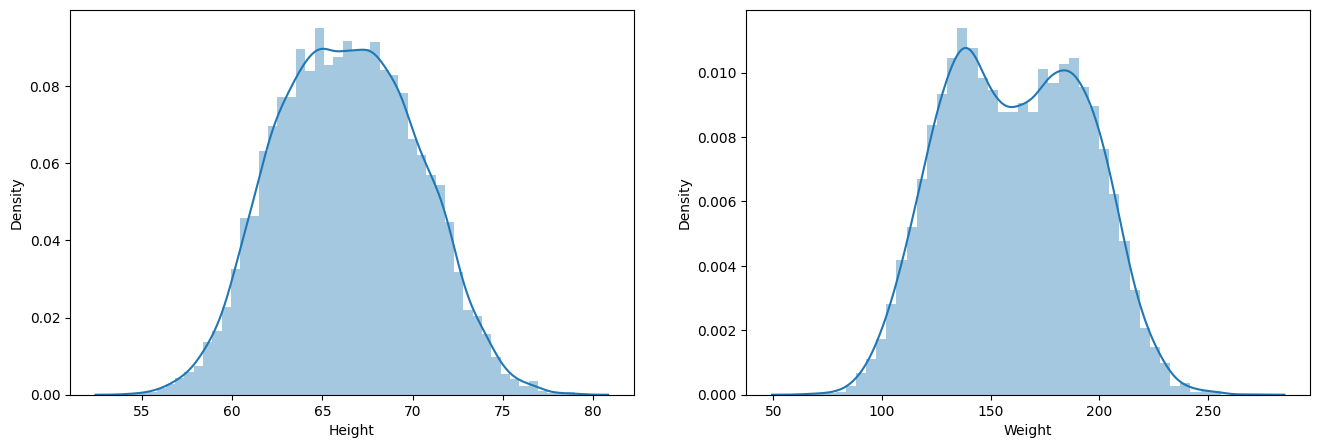

In [5]:
# Plotting
plt.figure(figsize=(16, 5))
plt.subplot(1,2,1)
sns.distplot(data['Height'])

plt.subplot(1,2,2)
sns.distplot(data['Weight'])

plt.show()

In [6]:
data['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

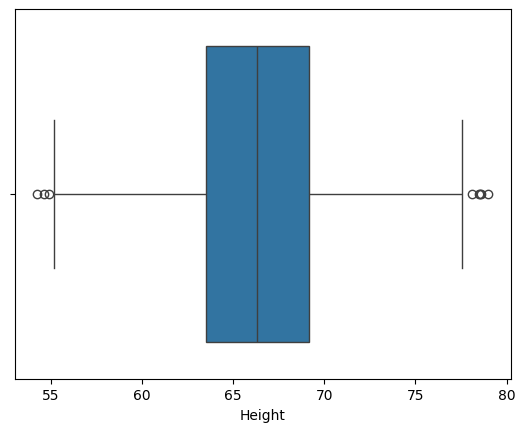

In [7]:
sns.boxplot(x=data['Height'])
plt.show()

In [10]:
p1 = data['Height'].quantile(0.01)
p99 = data['Height'].quantile(0.99)
print(p1)
print(p99)

58.13441158671655
74.7857900583366


### Triming

In [13]:
new_data = data[(data['Height'] < p99) & (data['Height'] > p1)]
new_data

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


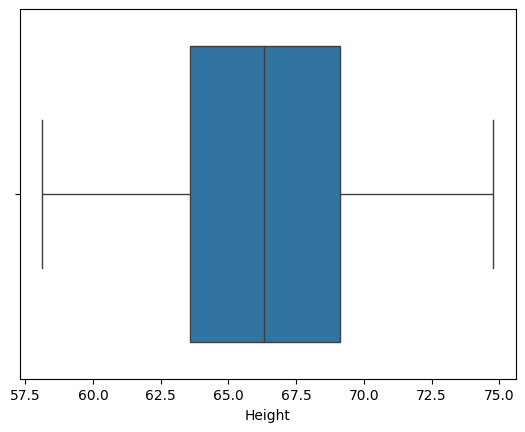

In [14]:
sns.boxplot(x=new_data['Height'])
plt.show()

### Capping

In [20]:
data['Height'] = np.where(data['Height'] > p99, p99, np.where(data['Height'] < p1, p1, data['Height']))

print("Max: ", data['Height'].max())
print("Min: ", data['Height'].min())

Max:  74.7857900583366
Min:  58.13441158671655
